### IIVP Challenge
This competition is to build a classifier that maps Hindi digits to the corresponding Latin digit labels 0–9. The Kaggle task is evaluated by accuracy on the predicted class. The dataset consists of images of handwritten Hindi digits, and the goal is to correctly classify each image into one of the ten classes (0-9).

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from skimage.feature import hog

In [2]:
TRAIN = "train.csv"
TEST = "test.csv"
TRAIN_DIR = "train/train"
TEST_DIR = "test/test"
SAMPLE_SUB = "sample_submission.csv"

# Load the dataset

In [3]:
train_df = pd.read_csv(TRAIN)
test_df = pd.read_csv(TEST)

print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)
print(train_df.head())

Train shape:  (17000, 2)
Test shape:  (3000, 1)
      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3


# Helper functions

In [4]:
def load_image(image_id, folder):
    # load image as grayscale float32 in [0,1]
    path = os.path.join(folder, f"{image_id}.png")
    img = cv2.imread(path, 0) # grayscale
    img = img.astype(np.float32) / 255.0
    return img

def load_train_dataset(df, folder):
    X_images = []
    y = []

    for i, row in df.iterrows():
        image_id = int(row["Id"])
        label = int(row["Category"])

        path = os.path.join(folder, str(label), f"{image_id}.png")
        img = cv2.imread(path, 0)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        img = img.astype(np.float32) / 255.0
        X_images.append(img)
        y.append(label)

        if i % 1000 == 0:
            print("Loaded", i, "images")

    return np.array(X_images, dtype=np.float32), np.array(y)

def compare_accuracy(model_name, raw_acc, hog_acc):
    import matplotlib.pyplot as plt

    raw_pct = raw_acc * 100
    hog_pct = hog_acc * 100
    increase_points = hog_pct - raw_pct
    increase_percent = ((hog_acc - raw_acc) / raw_acc) * 100 if raw_acc != 0 else 0

    fig, ax = plt.subplots(figsize=(8, 2.2))
    ax.axis("off")

    ax.text(0.02, 0.82, model_name, fontsize=16, fontweight="bold", transform=ax.transAxes)
    ax.text(0.02, 0.42, f"Initial: {raw_pct:.2f}%", fontsize=13, transform=ax.transAxes)
    ax.text(0.36, 0.42, "->", fontsize=18, fontweight="bold", transform=ax.transAxes)
    ax.text(0.45, 0.42, f"HOG: {hog_pct:.2f}%", fontsize=13, transform=ax.transAxes)

    ax.text(
        0.72, 0.42,
        f"+{increase_points:.2f} increase",
        fontsize=13,
        fontweight="bold",
        transform=ax.transAxes
    )
    ax.text(
        0.72, 0.18,
        f"({increase_percent:.2f}% relative increase)",
        fontsize=11,
        transform=ax.transAxes
    )

    # mini progress line
    line_y = 0.72
    x0, x1 = 0.02, 0.98
    ax.plot([x0, x1], [line_y, line_y], linewidth=6, alpha=0.2, transform=ax.transAxes, solid_capstyle="round")

    raw_x = x0 + (raw_pct / 100) * (x1 - x0)
    hog_x = x0 + (hog_pct / 100) * (x1 - x0)

    ax.plot([raw_x, hog_x], [line_y, line_y], linewidth=6, transform=ax.transAxes, solid_capstyle="round")
    ax.scatter([raw_x, hog_x], [line_y, line_y], s=90, transform=ax.transAxes, zorder=3)

    ax.text(raw_x, line_y + 0.08, f"{int(raw_pct)}%", ha="center", fontsize=10, transform=ax.transAxes)
    ax.text(hog_x, line_y + 0.08, f"{int(hog_pct)}%", ha="center", fontsize=10, transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

# Load Training Images

In [5]:
X_images, y = load_train_dataset(train_df, TRAIN_DIR)

print("Image array shape:", X_images.shape)
print("Labels shape:", y.shape)
print("Pixel min/max:", X_images.min(), X_images.max())

Loaded 0 images
Loaded 1000 images
Loaded 2000 images
Loaded 3000 images
Loaded 4000 images
Loaded 5000 images
Loaded 6000 images
Loaded 7000 images
Loaded 8000 images
Loaded 9000 images
Loaded 10000 images
Loaded 11000 images
Loaded 12000 images
Loaded 13000 images
Loaded 14000 images
Loaded 15000 images
Loaded 16000 images
Image array shape: (17000, 32, 32)
Labels shape: (17000,)
Pixel min/max: 0.0 1.0


# Visualize some samples

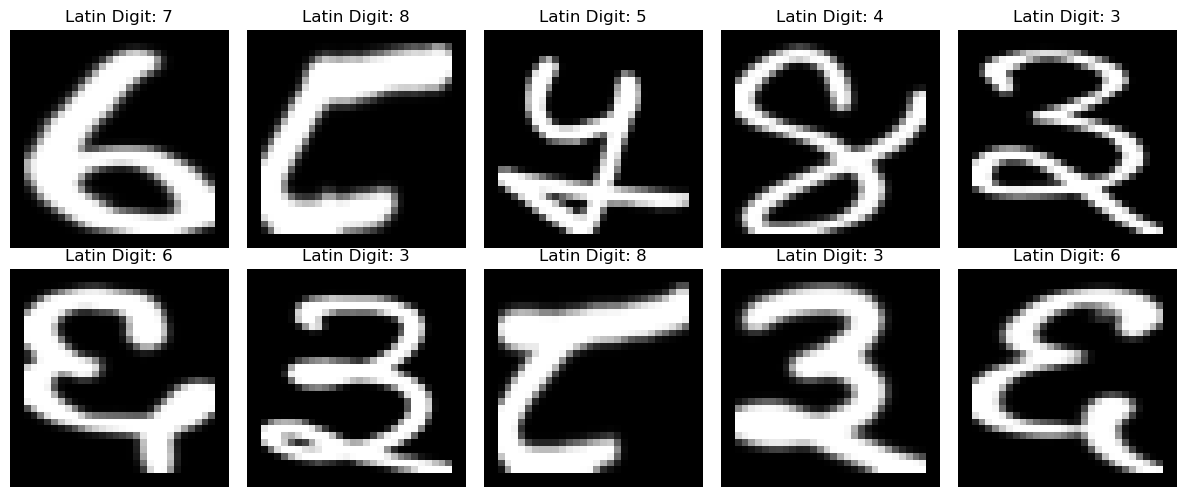

In [76]:
# get random set of samples
indices = np.random.choice(len(X_images), 10, replace=False)

plt.figure(figsize=(12, 5))
for plot_idx, img_idx in enumerate(indices):
    plt.subplot(2, 5, plot_idx + 1)
    plt.imshow(X_images[img_idx], cmap="gray")
    plt.title(f"Latin Digit: {y[img_idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Stratified train-test split
Split the training data into training and validation sets before applying the model on the official test set. This allows us to evaluate the model's performance on unseen data and helps prevent overfitting.

In [77]:
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_images,
    y,
    test_size = 0.2,
    random_state=69,
    stratify=y
)

print("Train: ", X_train_img.shape, y_train.shape)
print("Val: ", X_val_img.shape, y_val.shape)

Train:  (13600, 32, 32) (13600,)
Val:  (3400, 32, 32) (3400,)


# Flatten raw pixels - 32x32 to 1024 features

In [78]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_val_flat = X_val_img.reshape(len(X_val_img), -1)

print(X_train_flat.shape, X_val_flat.shape)

(13600, 1024) (3400, 1024)


# 1A: Logistic Regression

In [79]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=69)
)

logreg.fit(X_train_flat, y_train)
val_pred_logreg = logreg.predict(X_val_flat)

print("Logistic Regression Accuracy: ", accuracy_score(y_val, val_pred_logreg))

Logistic Regression Accuracy:  0.9352941176470588


# 1B: K-Nearest Neghbor (KNN)

In [80]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_flat, y_train)
val_pred_knn = knn.predict(X_val_flat)

print("KNN Accuracy: ", accuracy_score(y_val, val_pred_knn))

KNN Accuracy:  0.9814705882352941


# 1C: Support Vector Machine (SVM)

In [81]:
svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=5, gamma="scale", random_state=69)
)

svm.fit(X_train_flat, y_train)
val_pred_svm = svm.predict(X_val_flat)

print("SVM Accuracy: ", accuracy_score(y_val, val_pred_svm))

SVM Accuracy:  0.9923529411764705


From first round of tests, SVM performed the best with an accuracy of ~99.24% on the validation set. This suggests that SVM is a strong candidate for our final model.

# HOG Feature Extraction

In [82]:
def extract_hog(images):
    features = []
    for img in images:
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(4,4),
            cells_per_block=(2,2),
            block_norm="L2-Hys"
        )
        features.append(feat)
    return np.array(features, dtype=np.float32)

X_train_hog = extract_hog(X_train_img)
X_val_hog = extract_hog(X_val_img)

print("HOG train shape:", X_train_hog.shape)
print("HOG val shape:", X_val_hog.shape)

HOG train shape: (13600, 1764)
HOG val shape: (3400, 1764)


# 2A: HOG + Linear Regression

HOG + Logistic Regression Accuracy:  0.9882352941176471


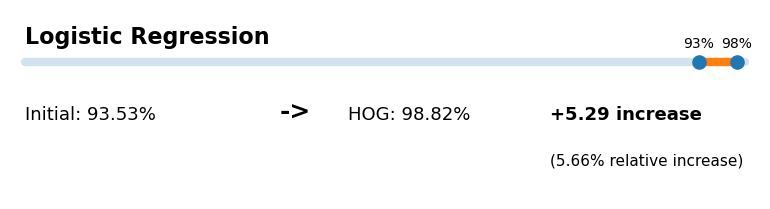

In [83]:
hog_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=69)
)

hog_logreg.fit(X_train_hog, y_train)
val_pred_hog_logreg = hog_logreg.predict(X_val_hog)

print("HOG + Logistic Regression Accuracy: ", accuracy_score(y_val, val_pred_hog_logreg))

compare_accuracy(
    "Logistic Regression",
    accuracy_score(y_val, val_pred_logreg),
    accuracy_score(y_val, val_pred_hog_logreg)
)

# 2B: HOG + KNN

HOG + KNN Accuracy:  0.9926470588235294


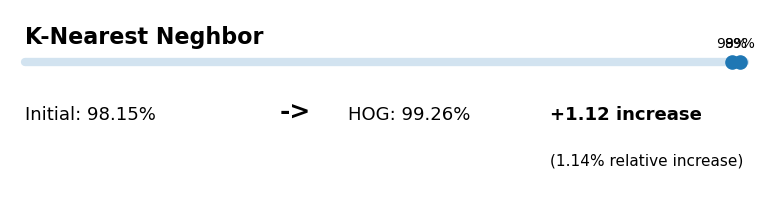

In [84]:
hog_knn = KNeighborsClassifier(n_neighbors=3)

hog_knn.fit(X_train_hog, y_train)
val_pred_hog_knn = hog_knn.predict(X_val_hog)

print("HOG + KNN Accuracy: ", accuracy_score(y_val, val_pred_hog_knn))

compare_accuracy(
    "K-Nearest Neghbor",
    accuracy_score(y_val, val_pred_knn),
    accuracy_score(y_val, val_pred_hog_knn)
)

# 2C: HOG + SVM

HOG + SVM Accuracy:  0.9961764705882353


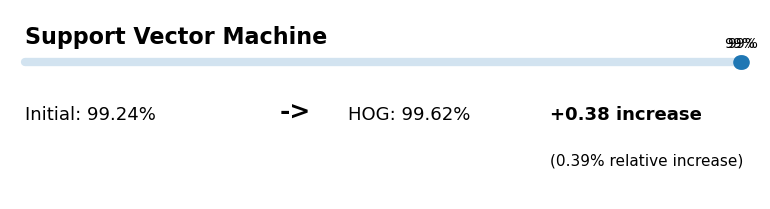

In [85]:
hog_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=5, gamma="scale", random_state=69)
)

hog_svm.fit(X_train_hog, y_train)
val_pred_hog_svm = hog_svm.predict(X_val_hog)

print("HOG + SVM Accuracy: ", accuracy_score(y_val, val_pred_hog_svm))

compare_accuracy(
    "Support Vector Machine",
    accuracy_score(y_val, val_pred_svm),
    accuracy_score(y_val, val_pred_hog_svm)
)

# Compare Scores

In [91]:
scores = {
    "Logistic Regression": accuracy_score(y_val, val_pred_logreg),
    "KNN": accuracy_score(y_val, val_pred_knn),
    "SVM": accuracy_score(y_val, val_pred_svm),
    "HOG + LR": accuracy_score(y_val, val_pred_hog_logreg),
    "HOG + KNN": accuracy_score(y_val, val_pred_hog_knn),
    "HOG + SVM": accuracy_score(y_val, val_pred_hog_svm),
}

scores_df = pd.DataFrame(scores.items(), 
                         columns=["Model", "Validation Accuracy"])
scores_df["Validation Accuracy (%)"] = scores_df["Validation Accuracy"] * 100
scores_df = scores_df.sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)
print(scores_df[["Model", "Validation Accuracy (%)"]])

                 Model  Validation Accuracy (%)
0            HOG + SVM                99.617647
1            HOG + KNN                99.264706
2                  SVM                99.235294
3             HOG + LR                98.823529
4                  KNN                98.147059
5  Logistic Regression                93.529412


# Error Analysis

In [96]:
# optional block - subject to change/deletion

best_name = scores_df.iloc[0]["Model"]
print("Best so far:", best_name)

if best_name == "Logistic Regression":
    best_model = logreg
    best_pred = val_pred_logreg
    X_for_analysis = X_val_flat

elif best_name == "KNN":
    best_model = knn
    best_pred = val_pred_knn
    X_for_analysis = X_val_flat

elif best_name == "SVM":
    best_model = svm
    best_pred = val_pred_svm
    X_for_analysis = X_val_flat

elif best_name == "HOG + Logistic Regression":
    best_model = hog
    best_pred = val_pred_hog_logreg
    X_for_analysis = X_val_hog

elif best_name == "HOG + KNN":
    best_model = hog
    best_pred = val_pred_hog_knn
    X_for_analysis = X_val_hog

elif best_name == "HOG + SVM":
    best_model = hog
    best_pred = val_pred_hog_svm
    X_for_analysis = X_val_hog

print(classification_report(y_val, best_pred, digits=6))

Best so far: HOG + SVM
              precision    recall  f1-score   support

           0   0.997067  1.000000  0.998532       340
           1   1.000000  0.997059  0.998527       340
           2   0.994118  0.994118  0.994118       340
           3   0.997033  0.988235  0.992614       340
           4   0.994152  1.000000  0.997067       340
           5   0.991202  0.994118  0.992658       340
           6   0.991254  1.000000  0.995608       340
           7   0.997041  0.991176  0.994100       340
           8   1.000000  1.000000  1.000000       340
           9   1.000000  0.997059  0.998527       340

    accuracy                       0.996176      3400
   macro avg   0.996187  0.996176  0.996175      3400
weighted avg   0.996187  0.996176  0.996175      3400



These results suggest that the HOG + SVM model has little to no trouble distinguishing 0, 1, 4, 8, 9. Digits 3 and 6 are very similar, as they are inherently the same but flipped

# Confusion Matrix

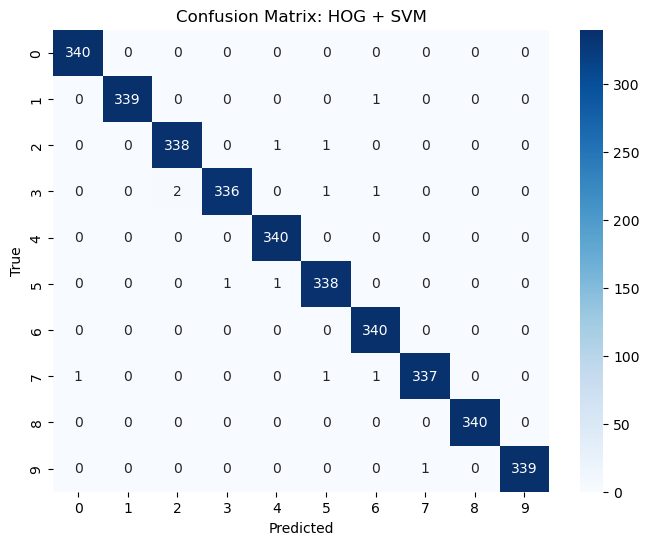

In [97]:
cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

# Show misclassified examples

Number of misclassifid samples:  13


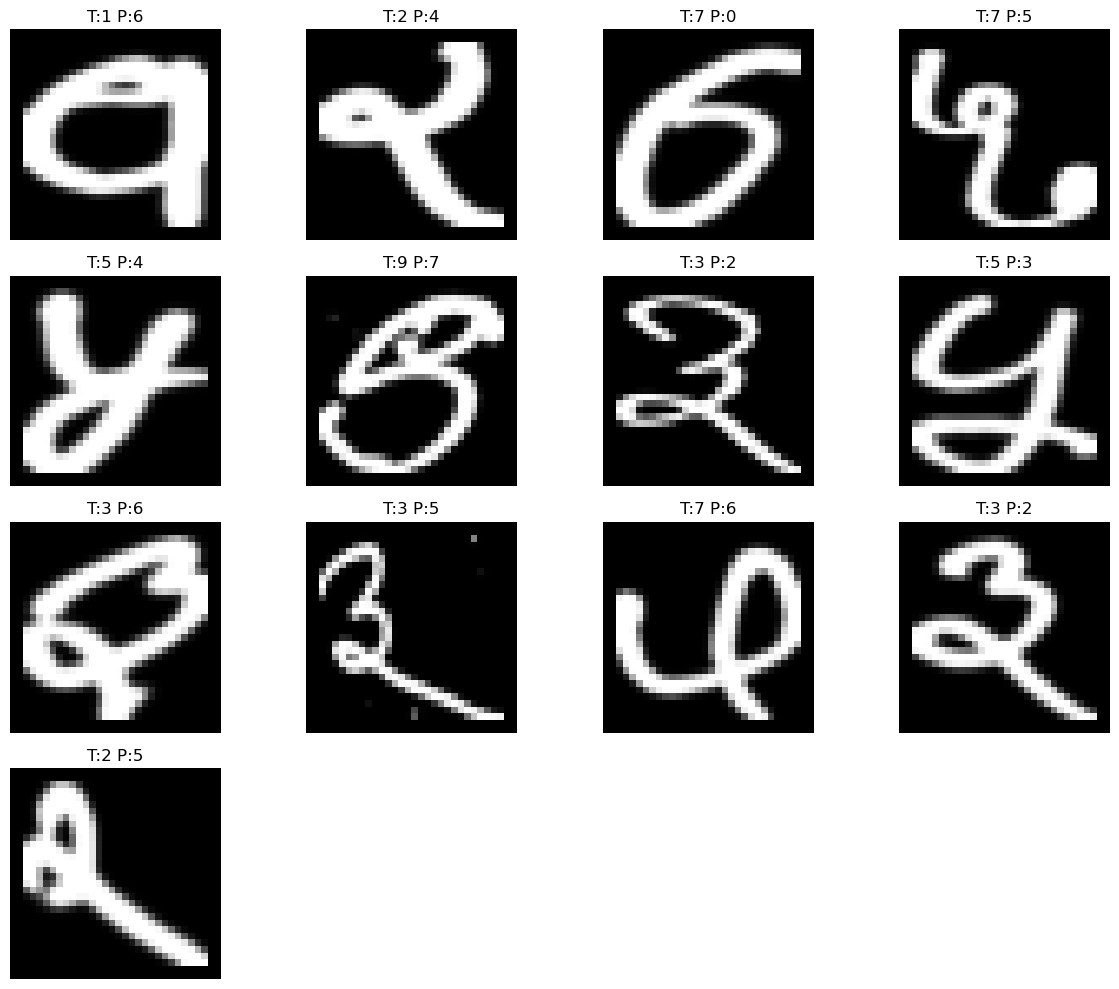

In [98]:
wrong_idx = np.where(best_pred != y_val)[0]
print("Number of misclassifid samples: ", len(wrong_idx))

plt.figure(figsize=(12,10))
n_show = min(16, len(wrong_idx))
for i in range(n_show):
    idx = wrong_idx[i]
    plt.subplot(4,4,i+1)
    plt.imshow(X_val_img[idx], cmap="gray")
    plt.title(f"T:{y_val[idx]} P:{best_pred[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()